In [1]:
from random import shuffle
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import isautilities as isau
import hoi
import xarray as xr
import scipy as sp

import pathlib
froot = pathlib.Path().cwd().parent.parent.parent / 'Results/Figures/ISAHpcPfc'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

/home/pietro/uvEnvs/hoi/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
import jax
def print_gpu_memory():
    for device in jax.devices("gpu"):
        stats = device.memory_stats()
        gib = 1024**3

        print(
            f"{device}: "
            f"in use={stats['bytes_in_use']/gib:.2f} GiB, "
            f"peak={stats['peak_bytes_in_use']/gib:.2f} GiB, "
            f"pool={stats['pool_bytes']/gib:.2f} GiB / "
            f"{stats['bytes_limit']/gib:.2f} GiB"
        )

In [2]:
def _regionTE(session,regs=None,when='sleep.*#0',bin=0.005,delay=1,shuffle=0,verbose=False):
    # note: no overlapping bins for time independence

    delay = np.array(delay,ndmin=1)

    R = fma.regions.regions(session,phases=when,states='sws',events='InfraSlowRhythm/infraslowaval')
    regs = R.ids if regs is None else np.asarray(regs)[np.isin(regs,R.ids)]
    isa = R.eventIntervals('slownr')
    nrem = R.eventIntervals('sws')

    fr = R.firingRate(regs=regs,window=bin) # (time, region)
    is_isa = isau.isISA(fr,isa,nrem)
    fr = (fr[:,1:] * bin).astype(int)
    verbose and print('zeros:',', '.join([f'{regs[i]} {p:.2f}%' for i, p in enumerate((fr==0).mean(axis=0) * 100)]))

    def te(model,d): return model.fit(method='binning',tau=d,matrix=True)[:,:,0] # (region, region)
    rng = np.random.default_rng()
    shifts = rng.integers(low=-int(2/bin), high=int(2/bin), size=(shuffle,len(regs))) # circular shifts in [-2,2] s

    fit = np.full((len(delay),2,len(regs),len(regs),shuffle+1),np.nan)
    for a in range(2): # 0: ISA, 1: nISA
        verbose and print(f'ISA: {not a}')
        this_fr = fr[is_isa==a]

        # observed
        model = hoi.metrics.TransferEntropy(this_fr,verbose=False)
        for i, d in enumerate(delay):
            fit[i,a,:,:,0] = te(model,d) # (region, region)

        # surrogate
        verbose and print(f'shuffles (out of {shuffle}): ',end='')
        for k in range(shuffle):
            verbose and print(f'{k} ',end='')
            fr_sh = fma.general.circularShift(this_fr,shifts[k],axis=0)
            model = hoi.metrics.TransferEntropy(fr_sh,verbose=False)
            for i, d in enumerate(delay):
                fit[i,a,:,:,k+1] = te(model,d) # (region, region)
        verbose and print()

    t = delay * bin
    fit = xr.DataArray(fit,dims=['d','isa','reg0','reg1','shuffle'],coords={'d': t, 'isa': [True,False], 'reg0': regs, 'reg1': regs, 'shuffle': [False]+[True]*shuffle, 'rat': int(R.rat)})

    return fit

In [3]:
# test on one session
regs = ['hpc','nr','pfc']
session = fma.data.readBatchFile(batch_file)[0][23]
print(session)
sfit = _regionTE(session,delay=8,shuffle=10,verbose=True)

/mnt/hubel-data-140/karadoc/Rat004_20240311/Rat004_20240311.xml
zeros: hpc 18.15%, nr 42.92%, pfc 51.46%
ISA: True
shuffles (out of 10): 0 1 2 3 4 5 6 7 8 9 
ISA: False
shuffles (out of 10): 0 1 2 3 4 5 6 7 8 9 


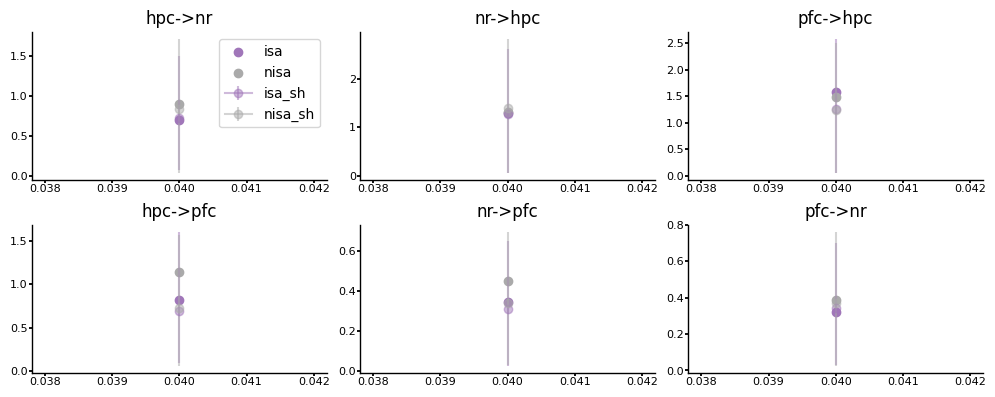

In [12]:
fig, ax = fma.plotting.makeFigure(size=(25,10),n=(2,len(regs)))
k = 0
for i, r0 in enumerate(regs):
    for j, r1 in enumerate(regs):
        if r0 != r1:
            i, j = np.unravel_index(k,ax.shape,order='F')
            f = sfit.sel(reg0=r0,reg1=r1) * 1000
            fma.plotting.semPlot(sfit.d,f.sel(isa=True,shuffle=True).T,label='isa_sh',ax=ax[i,j],color=isau.paperColors('nr','80'),alpha=0.3)
            fma.plotting.semPlot(sfit.d,f.sel(isa=False,shuffle=True).T,label='nisa_sh',ax=ax[i,j],color=isau.paperColors('shuffle','80'),alpha=0.3)
            ax[i,j].scatter(sfit.d,f.sel(isa=True,shuffle=False),label='isa',color=isau.paperColors('nr'))
            ax[i,j].scatter(sfit.d,f.sel(isa=False,shuffle=False),label='nisa',color=isau.paperColors('shuffle'))
            ax[i,j].set(title=f'{r0}->{r1}')
            k += 1
ax[0,0].legend();

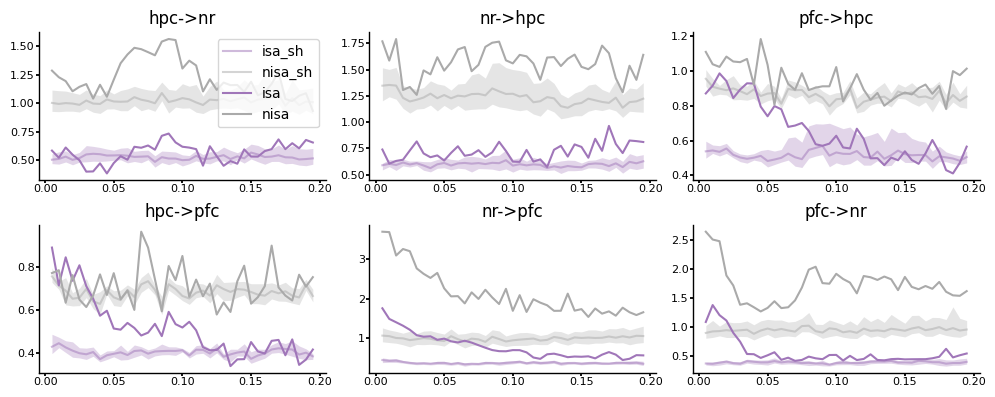

In [5]:
fig, ax = fma.plotting.makeFigure(size=(25,10),n=(2,len(regs)))
k = 0
for i, r0 in enumerate(regs):
    for j, r1 in enumerate(regs):
        if r0 != r1:
            i, j = np.unravel_index(k,ax.shape,order='F')
            f = sfit.sel(reg0=r0,reg1=r1) * 1000
            fma.plotting.semPlot(sfit.d,f.sel(isa=True,shuffle=True).T,label='isa_sh',ax=ax[i,j],color=isau.paperColors('nr','80'),alpha=0.3)
            fma.plotting.semPlot(sfit.d,f.sel(isa=False,shuffle=True).T,label='nisa_sh',ax=ax[i,j],color=isau.paperColors('shuffle','80'),alpha=0.3)
            ax[i,j].plot(sfit.d,f.sel(isa=True,shuffle=False),label='isa',color=isau.paperColors('nr'))
            ax[i,j].plot(sfit.d,f.sel(isa=False,shuffle=False),label='nisa',color=isau.paperColors('shuffle'))
            ax[i,j].set(title=f'{r0}->{r1}')
            k += 1
ax[0,0].legend();

run batch

In [3]:
sessions = np.arange(0,58,3)
regs = ['hpc','nr','pfc']
fit = fma.data.runBatch(batch_file,_regionTE,kwargs={'regs': regs, 'delay': 10, 'shuffle': 30, 'verbose': True},sessions=sessions)
fit_cat = xr.concat([d for d in fit if d is not None],dim='rat',join='outer',coords='all')
t_max = fit_cat.values.argmax(axis=1)
t_max = xr.DataArray(fit_cat.d.values[t_max],coords=[fit_cat.rat,fit_cat.isa,fit_cat.reg0,fit_cat.reg1,fit_cat.shuffle])
# significance (1 lag)
z = (fit_cat.sel(shuffle=False) - fit_cat.sel(shuffle=True).mean(dim='shuffle')) / fit_cat.sel(shuffle=True).std(dim='shuffle')
h = sp.stats.wilcoxon(z.isel(d=0).values,axis=0,nan_policy='omit').pvalue
_, h = fma.analysis.holmBonferroni(h,return_reject=True)


Starting Batch, 2026-09-02 15:40:05.820580 

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231212/Rat003_20231212.xml, 1 out of 20
zeros: hpc 67.47%, nr 73.17%, pfc 84.80%
ISA: True
shuffles (out of 30): 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 
ISA: False
shuffles (out of 30): 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231215/Rat003_20231215.xml, 2 out of 20
zeros: hpc 39.42%, nr 35.96%, pfc 65.15%
ISA: True
shuffles (out of 30): 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 
ISA: False
shuffles (out of 30): 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231221/Rat003_20231221.xml, 3 out of 20
zeros: hpc 45.14%, nr 37.38%, pfc 46.11%
ISA: True
shuffles (out of 30): 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23

/mnt/hubel-data-103/Pietro/Code/Python/RegionsPython/fmatoolbox/src/fmatoolbox/plotting.py:342: RuntimeWarning: Mean of empty slice
  y_line = np.nanmean(y,axis=0)
/home/pietro/uvEnvs/hoi/lib/python3.12/site-packages/scipy/stats/_resampling.py:155: RuntimeWarning: invalid value encountered in divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/home/pietro/uvEnvs/hoi/lib/python3.12/site-packages/scipy/_lib/_util.py:365: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


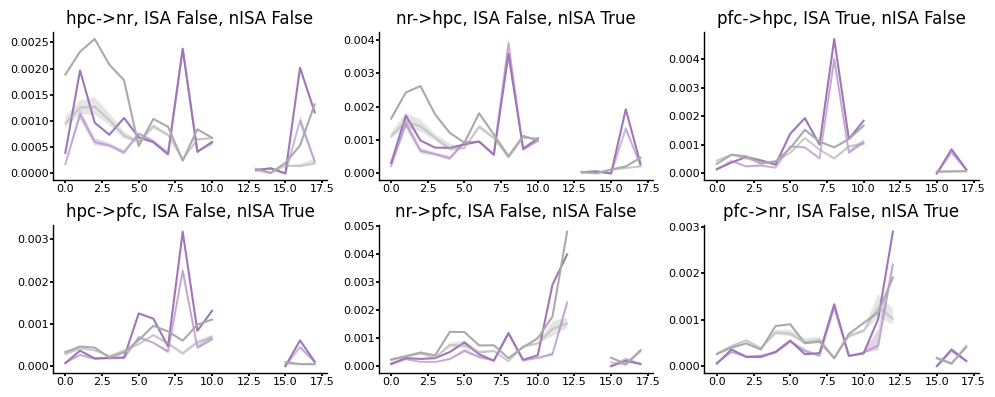

In [26]:
fig, ax = fma.plotting.makeFigure(size=(25,10),n=(2,len(regs)))
k = 0
for i, r0 in enumerate(regs):
    for j, r1 in enumerate(regs):
        if r0 != r1:
            i, j = np.unravel_index(k,ax.shape,order='F')
            f = fit_cat.sel(reg0=r0,reg1=r1).isel(d=0)
            fma.plotting.semPlot(range(f.shape[0]),f.sel(isa=True,shuffle=False),label='isa',ax=ax[i,j],color=isau.paperColors('nr'))
            fma.plotting.semPlot(range(f.shape[0]),f.sel(isa=True,shuffle=True).T,label='isa_sh',ax=ax[i,j],color=isau.paperColors('nr','80'),alpha=0.3)

            fma.plotting.semPlot(range(f.shape[0]),f.sel(isa=False,shuffle=False),label='nisa',ax=ax[i,j],color=isau.paperColors('shuffle'))
            fma.plotting.semPlot(range(f.shape[0]),f.sel(isa=False,shuffle=True).T,label='nisa_sh',ax=ax[i,j],color=isau.paperColors('shuffle','80'),alpha=0.3)
            ax[i,j].set(title=f'{r0}->{r1}, ISA {h[0,i,j]}, nISA {h[1,i,j]}')
            k += 1

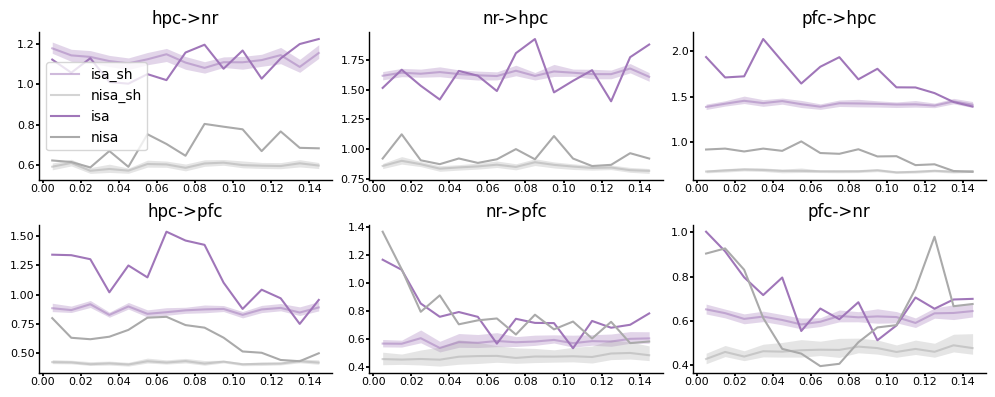

In [83]:
# see examples
s = 4
fig, ax = fma.plotting.makeFigure(size=(25,10),n=(2,len(regs)))
k = 0
for i, r0 in enumerate(regs):
    for j, r1 in enumerate(regs):
        if r0 != r1:
            i, j = np.unravel_index(k,ax.shape,order='F')
            f = fit_cat.isel(rat=s).sel(reg0=r0,reg1=r1) * 1000
            fma.plotting.semPlot(f.d,f.sel(isa=True,shuffle=True).T,label='isa_sh',ax=ax[i,j],color=isau.paperColors('nr','80'),alpha=0.3)
            fma.plotting.semPlot(f.d,f.sel(isa=False,shuffle=True).T,label='nisa_sh',ax=ax[i,j],color=isau.paperColors('shuffle','80'),alpha=0.3)
            ax[i,j].plot(f.d,f.sel(isa=True,shuffle=False),label='isa',color=isau.paperColors('nr'))
            ax[i,j].plot(f.d,f.sel(isa=False,shuffle=False),label='nisa',color=isau.paperColors('shuffle'))
            ax[i,j].set(title=f'{r0}->{r1}')
            k += 1
ax[0,0].legend();

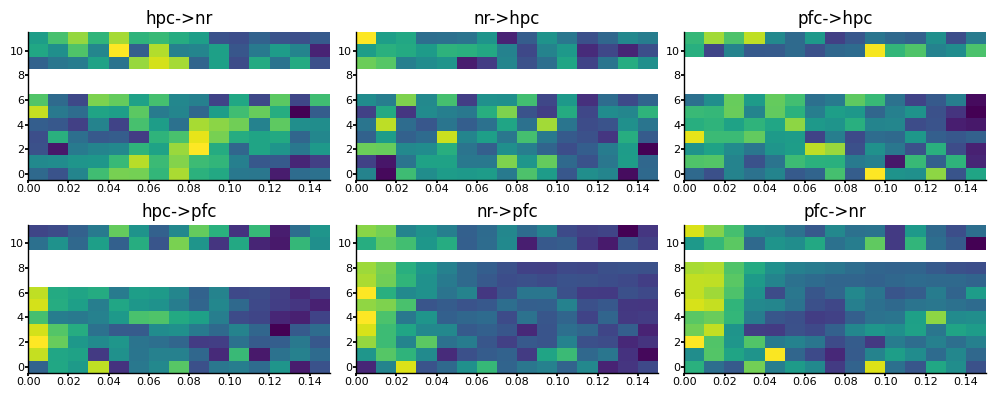

In [61]:
# see examples
fig, ax = fma.plotting.makeFigure(size=(25,10),n=(2,len(regs)))
a = False
k = 0
for i, r0 in enumerate(regs):
    for j, r1 in enumerate(regs):
        if r0 != r1:
            i, j = np.unravel_index(k,ax.shape,order='F')
            f = fit_cat.sel(reg0=r0,reg1=r1)
            fma.plotting.plotColorMap(f.sel(isa=a,shuffle=False),x=f.d,ax=ax[i,j],zscore=1)
            #fma.plotting.semPlot(f.d,f.sel(isa=False,shuffle=True).T,label='nisa_sh',ax=ax[i,j],color=isau.paperColors('shuffle','80'),alpha=0.3)
            #ax[i,j].plot(f.d,f.sel(isa=True,shuffle=False),label='isa',color=isau.paperColors('nr'))
            #ax[i,j].plot(f.d,f.sel(isa=False,shuffle=False),label='nisa',color=isau.paperColors('shuffle'))
            ax[i,j].set(title=f'{r0}->{r1}')
            k += 1

In [ ]:
fig, ax = fma.plotting.makeFigure(size=(25,10),n=(2,len(regs)))
k = 0
for i, r0 in enumerate(regs):
    for j, r1 in enumerate(regs):
        if r0 != r1:
            i, j = np.unravel_index(k,ax.shape,order='F')
            f = fit_cat.sel(reg0=r0,reg1=r1) * 1000
            fma.plotting.semPlot(fit_cat.d,f.sel(isa=True,shuffle=False),label='isa',ax=ax[i,j])
            fma.plotting.semPlot(fit_cat.d,f.sel(isa=False,shuffle=False),label='nisa',ax=ax[i,j])
            ax[i,j].set(title=f'{r0}->{r1}')
            k += 1
ax[0,0].legend();

In [7]:
# find peaks with unexpected value
peak = fit_cat.max(dim='d')
p_val = xr.DataArray(fma.analysis.MCpValue(np.permute_dims(peak.sel(shuffle=True).values,(-1,0,1,2,3)), peak.sel(shuffle=False)), coords=[fit_cat.rat,fit_cat.isa,fit_cat.reg0,fit_cat.reg1])

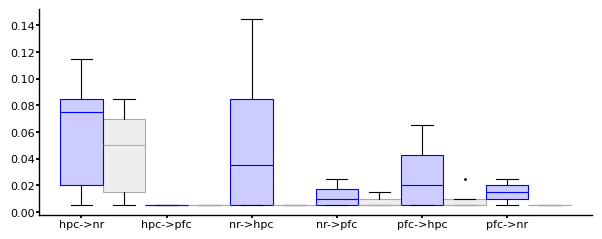

In [78]:
fig, ax = fma.plotting.makeFigure(size=(15,6))
x = np.arange(6)
data_isa = []
data_nisa = []
names = []
for i, r0 in enumerate(regs):
    for j, r1 in enumerate(regs):
        if r0 != r1:
            t = t_max.sel(isa=True,reg0=r0,reg1=r1,shuffle=False).values
            data_isa.append(t[p_val.sel(isa=True,reg0=r0,reg1=r1).values < 0.05])
            t = t_max.sel(isa=False,reg0=r0,reg1=r1,shuffle=False).values
            data_nisa.append(t[p_val.sel(isa=False,reg0=r0,reg1=r1).values < 0.05])
            names.append(f'{r0}->{r1}')
fma.plotting.boxPlot(data_nisa,x=x+0.5,ax=ax[0],color=isau.paperColors('shuffle'))
fma.plotting.boxPlot(data_isa,x=x,ax=ax[0],label=names)

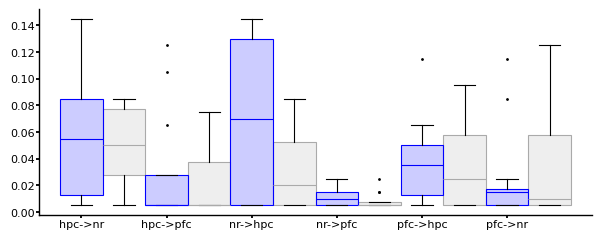

In [81]:
fig, ax = fma.plotting.makeFigure(size=(15,6))
x = np.arange(6)
data_isa = []
data_nisa = []
names = []
for i, r0 in enumerate(regs):
    for j, r1 in enumerate(regs):
        if r0 != r1:
            t = t_max.sel(isa=True,reg0=r0,reg1=r1,shuffle=False).values
            data_isa.append(t)
            t = t_max.sel(isa=False,reg0=r0,reg1=r1,shuffle=False).values
            data_nisa.append(t)
            names.append(f'{r0}->{r1}')
fma.plotting.boxPlot(data_nisa,x=x+0.5,ax=ax[0],color=isau.paperColors('shuffle'))
fma.plotting.boxPlot(data_isa,x=x,ax=ax[0],label=names)

0.045


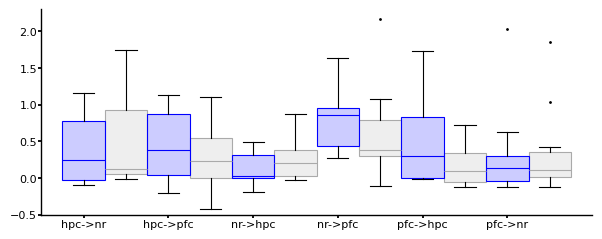

In [77]:
fig, ax = fma.plotting.makeFigure(size=(15,6))
t = 4
print(fit_cat.d[t].values)
x = np.arange(6)
data = [[],[]]
names = []
for i, r0 in enumerate(regs):
    for j, r1 in enumerate(regs):
        if r0 != r1:
            for a in range(2):
                shuffle_mean = fit_cat.sel(isa=not a,reg0=r0,reg1=r1,shuffle=True).mean(dim='shuffle').isel(d=t)
                data[a].append( (fit_cat.sel(isa=not a,reg0=r0,reg1=r1,shuffle=False).isel(d=t)-shuffle_mean) / shuffle_mean)
            names.append(f'{r0}->{r1}')
fma.plotting.boxPlot(data[1],x=x+0.5,ax=ax[0],color=isau.paperColors('shuffle'))
fma.plotting.boxPlot(data[0],x=x,ax=ax[0],label=names)
ax[0].set(ylim=[-0.5,2.3]);